## 07_ Macroeconomic_Feature_Store

Explainable AI Credit Risk Decision Platform Integrating Structured Borrower Data, NLP-Driven Text Intelligence, and Macroeconomic Indicators for Transparent Lending Decisions.

#### Purpose :
This notebook creates the enterprise Macroeconomic Feature Store by combining processed GDELT news sentiment features with FRED macroeconomic indicators.

In [48]:
# IMPORTS & CONFIGURATION
# __________________________________________________

from __future__ import annotations
import logging
import platform

# Standard Library
# -----------------------------
import warnings
from pathlib import Path
from datetime import datetime

# Data Processing
# -----------------------------
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Project Metadata
# -----------------------------
PROJECT_NAME = "Explainable AI Credit Risk Decision Platform"

NOTEBOOK_NAME = "07_enterprise_macroeconomic_feature_store"

VERSION = "1.0.0"

PRIMARY_KEY = "YearMonth"

# Reproducibility
# -----------------------------
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

# Display Settings
# -----------------------------
pd.set_option("display.max_columns", None)

pd.set_option("display.width", 200)

# Notebook Banner
# -----------------------------
print(PROJECT_NAME)
print("=" * 50)
print(f"Notebook : {NOTEBOOK_NAME}")
print(f"Execution: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Explainable AI Credit Risk Decision Platform
Notebook : 07_enterprise_macroeconomic_feature_store
Execution: 2026-07-15 10:05:36


In [8]:
# Directory Structure
# -----------------------------
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"

RAW_DIR = DATA_DIR / "raw"

PROCESSED_DIR = DATA_DIR / "processed"

MACRO_DIR = PROCESSED_DIR / "macro"

REPORT_DIR = PROJECT_ROOT / "reports"

MACRO_REPORT_DIR = REPORT_DIR / "macro"

FIGURE_DIR = MACRO_REPORT_DIR / "figures"

LOG_DIR = PROJECT_ROOT / "logs"

METADATA_DIR = MACRO_REPORT_DIR / "metadata"

VALIDATION_DIR = MACRO_REPORT_DIR / "validation"

FEATURE_STORE_DIR = PROJECT_ROOT / "feature_store"

# Create Output Directories
# -----------------------------
FEATURE_STORE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
# AUTOMATIC FOLDER CREATION
# ----------------------------------

DIRECTORIES = [

    RAW_DIR,

    PROCESSED_DIR,

    MACRO_DIR,

    REPORT_DIR,

    MACRO_REPORT_DIR,

    FIGURE_DIR,

    LOG_DIR,

    METADATA_DIR,

    VALIDATION_DIR,

    FEATURE_STORE_DIR]

for directory in DIRECTORIES:

    directory.mkdir(parents=True, exist_ok=True)

print("Project folders successfully verified.")
print("=" * 50)

for directory in DIRECTORIES:

    print(f"✓ {directory.relative_to(PROJECT_ROOT)}")

Project folders successfully verified.
✓ data/raw
✓ data/processed
✓ data/processed/macro
✓ reports
✓ reports/macro
✓ reports/macro/figures
✓ logs
✓ reports/macro/metadata
✓ reports/macro/validation
✓ feature_store


In [12]:
# LOGGING CONFIGURATION
# ----------------------

LOG_FILE = LOG_DIR / "08_macroeconomic_feature_store.log"

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    handlers=[logging.FileHandler(LOG_FILE),
              
              logging.StreamHandler()],
    
    force=True)

logger = logging.getLogger(__name__)

In [13]:
# LOG NOTEBOOK EXECUTION
# -----------------------

logger.info("ENTERPRISE MACROECONOMIC FEATURE STORE")

logger.info("=" * 40)

logger.info(f"Execution Time : {datetime.now()}")

logger.info("Folder structure successfully verified.")

2026-07-15 09:46:42,038 | INFO | ENTERPRISE MACROECONOMIC FEATURE STORE
2026-07-15 09:46:42,041 | INFO | ========================================
2026-07-15 09:46:42,042 | INFO | Execution Time : 2026-07-15 09:46:42.042007
2026-07-15 09:46:42,043 | INFO | Folder structure successfully verified.


#### Load Processed MacroEconomic Data

In [17]:
# DEFINE INPUT FILES
# ----------------------------------------------

FRED_FILE = MACRO_DIR / "fred_monthly_features.csv"

GDELT_FILE = MACRO_DIR / "gdelt_monthly_features.csv"

print("Files to Load")
print("-" * 60)
print(f"FRED  : {FRED_FILE.name}")
print(f"GDELT : {GDELT_FILE.name}")

Files to Load
------------------------------------------------------------
FRED  : fred_monthly_features.csv
GDELT : gdelt_monthly_features.csv


In [23]:
# VERIFY FILES
# ---------------------------

FRED_DIR = PROJECT_ROOT / "data" / "external" / "fred"

GDELT_DIR = PROJECT_ROOT / "data" / "external" / "gdelt"

FRED_FILE = FRED_DIR / "fred_monthly_features.csv"

GDELT_FILE = GDELT_DIR / "gdelt_monthly_features.csv"

print("Feature Store Locations")
print("-"*60)

print(FRED_FILE)

print(GDELT_FILE)

Feature Store Locations
------------------------------------------------------------
/Users/emmanuelahadzi/data/external/fred/fred_monthly_features.csv
/Users/emmanuelahadzi/data/external/gdelt/gdelt_monthly_features.csv


In [24]:
# load dataset
# ____________________________________________________

fred_df = pd.read_csv(FRED_FILE)

gdelt_df = pd.read_csv(GDELT_FILE)

fred_df.head()

gdelt_df.head()

,MONTH,Articles,BANK,BANKRUPTCY,LOAN,CREDIT,DEBT,DEFAULT,MORTGAGE,HOUSING,EMPLOYMENT,UNEMPLOYMENT,INFLATION,RECESSION,INTEREST_RATE,FEDERAL_RESERVE,ECONOMY,Average_Tone
0,2015-02-01,2260527,52576,26226,97,6306,51625,0,10,31548,29818,29665,25569,0,31258,0,381,-1.217589
1,2015-03-01,71368,3211,518,8,528,3056,0,4,2411,3479,1054,1167,0,1425,0,25,-1.129146
2,2015-04-01,67180,2605,436,7,556,2453,0,0,2114,3090,843,742,0,1053,0,23,-1.199136
3,2015-05-01,68502,2505,566,1,623,2683,0,0,2202,3215,992,811,0,996,0,29,-1.143442
4,2015-06-01,68922,3055,1097,10,777,2992,0,1,2106,3047,873,675,0,843,0,29,-1.290044


In [25]:
# STANDARDISE DATE KEYS
# ______________________________________________________

logger.info("Standardising date keys...")

# FRED
# ---------------------------------------------------------
fred_df["DATE"] = pd.to_datetime(fred_df["DATE"])

fred_df["YearMonth"] = fred_df["DATE"].dt.to_period("M").astype(str)

# GDELT
# ---------------------------------------------------------
gdelt_df["MONTH"] = pd.to_datetime(gdelt_df["MONTH"])

gdelt_df["YearMonth"] = gdelt_df["MONTH"].dt.to_period("M").astype(str)

logger.info("Date standardisation complete.")

print("FRED Date Range")
print(fred_df["YearMonth"].min(), "->", fred_df["YearMonth"].max())

print()

print("GDELT Date Range")
print(gdelt_df["YearMonth"].min(), "->", gdelt_df["YearMonth"].max())

2026-07-15 10:03:30,966 | INFO | Standardising date keys...
2026-07-15 10:03:30,995 | INFO | Date standardisation complete.


FRED Date Range
2007-01 -> 2018-12

GDELT Date Range
2015-02 -> 2018-12


In [26]:
# Validate Merge Keys
# ---------------------

display(fred_df[["DATE", "YearMonth"]].head())

display(gdelt_df[["MONTH", "YearMonth"]].head())

,DATE,YearMonth
0,2007-01-01,2007-01
1,2007-02-01,2007-02
2,2007-03-01,2007-03
3,2007-04-01,2007-04
4,2007-05-01,2007-05


,MONTH,YearMonth
0,2015-02-01,2015-02
1,2015-03-01,2015-03
2,2015-04-01,2015-04
3,2015-05-01,2015-05
4,2015-06-01,2015-06


#### Automated Data Validation

In [27]:
# Create Validation Report Folder
# -----------------------------------

VALIDATION_DIR = REPORT_DIR / "macroeconomic"

VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

logger.info(f"Validation reports will be saved to: {VALIDATION_DIR}")

# Reusable Validation Function
# ----------------------------------

def validate_dataset(df, dataset_name):

    logger.info(f"Validating {dataset_name} dataset...")

    report = {

        "Dataset": dataset_name,

        "Rows": len(df),

        "Columns": df.shape[1],

        "Duplicate Rows": int(df.duplicated().sum()),

        "Total Missing Values": int(df.isna().sum().sum()),

        "Unique Months": df["YearMonth"].nunique(),

        "Start Month": df["YearMonth"].min(),

        "End Month": df["YearMonth"].max()}

    return report

2026-07-15 10:03:39,808 | INFO | Validation reports will be saved to: /Users/emmanuelahadzi/reports/macroeconomic


In [28]:
# Validate Datasets
# -------------------

fred_report = validate_dataset(fred_df, "FRED")

gdelt_report = validate_dataset(gdelt_df, "GDELT")

validation_summary = pd.DataFrame([fred_report,gdelt_report])

display(validation_summary)

# Save Validation Summary
# ---------------------------

validation_summary.to_csv(VALIDATION_DIR / "validation_summary.csv",index=False)

logger.info("Validation summary saved.")

2026-07-15 10:03:42,441 | INFO | Validating FRED dataset...
2026-07-15 10:03:42,452 | INFO | Validating GDELT dataset...


,Dataset,Rows,Columns,Duplicate Rows,Total Missing Values,Unique Months,Start Month,End Month
0,FRED,144,22,0,0,144,2007-01,2018-12
1,GDELT,47,19,0,0,47,2015-02,2018-12


2026-07-15 10:03:42,464 | INFO | Validation summary saved.


In [103]:
# Drop Month in gdelt
# ___________________________________

gdelt_df = gdelt_df.drop(columns=["MONTH"],errors="ignore")

In [104]:
# Numerical Feature Summary
# ---------------------------

fred_statistics = fred_df.describe().T

gdelt_statistics = gdelt_df.describe().T

fred_statistics.to_csv(VALIDATION_DIR / "fred_statistics.csv")

gdelt_statistics.to_csv(VALIDATION_DIR / "gdelt_statistics.csv")

display(fred_statistics.head())

display(gdelt_statistics.head())

,count,mean,min,25%,50%,75%,max,std
DATE,144,2012-12-15 17:00:00,2007-01-01 00:00:00,2009-12-24 06:00:00,2012-12-16 12:00:00,2015-12-08 18:00:00,2018-12-01 00:00:00,NaN
Year,144.0,2012.5,2007.0,2009.75,2012.5,2015.25,2018.0,3.464102
Month,144.0,6.5,1.0,3.75,6.5,9.25,12.0,3.464102
Quarter,144.0,2.5,1.0,1.75,2.5,3.25,4.0,1.121936
FEDFUNDS,144.0,0.923403,0.07,0.12,0.18,1.1525,5.26,1.435961


,count,mean,std,min,25%,50%,75%,max
Articles,47.0,119701.191489,319228.806421,52187.0,67128.0,71325.0,81812.0,2260527.0
BANK,47.0,3520.957447,7330.308550,1501.0,2085.0,2473.0,2770.0,52576.0
BANKRUPTCY,47.0,916.723404,3785.172426,163.0,247.0,278.0,355.5,26226.0
LOAN,47.0,7.319149,14.126919,0.0,2.0,4.0,7.5,97.0
CREDIT,47.0,658.212766,858.407016,225.0,408.5,528.0,636.5,6306.0


### BUILD THE ENTERPRISE MACROECONOMIC FEATURE STORE

##### Purpose
##### ----------------------------------------------------------------------
##### Merge the validated FRED and GDELT feature stores into a unified monthly
##### Macroeconomic Feature Store.

In [105]:
# Ensure Merge Key Exists
# ------------------------------------------------------------------

def ensure_yearmonth(df, date_column):
    """
    Ensure a standard YearMonth key exists for monthly joins.
    """
    if "YearMonth" not in df.columns:
        df[date_column] = pd.to_datetime(df[date_column])
        df["YearMonth"] = df[date_column].dt.to_period("M").astype(str)
    return df

fred_df = ensure_yearmonth(fred_df, "DATE")
gdelt_df = ensure_yearmonth(gdelt_df, "MONTH")

logger.info("Merge keys verified.")

2026-07-16 21:50:39,997 | INFO | Merge keys verified.


In [106]:
# REMOVE DUPLICATE MONTHS
# ---------------------------------------------

fred_df = fred_df.drop_duplicates(subset="YearMonth")

gdelt_df = gdelt_df.drop_duplicates(subset="YearMonth")

logger.info("Duplicate monthly records removed.")

2026-07-16 21:50:44,860 | INFO | Duplicate monthly records removed.


In [107]:
# MERGE FEATURE STORES
# ----------------------------

macroeconomic_feature_store = pd.merge(

    fred_df,

    gdelt_df,

    how="left",

    on="YearMonth",

    suffixes=("_FRED", "_GDELT"))

logger.info("Feature stores successfully merged.")

2026-07-16 21:50:48,591 | INFO | Feature stores successfully merged.


In [108]:
# Fill GDELT variables with zero
# ------------------------------------------

gdelt_columns = [

    "Articles",
    "BANK",
    "BANKRUPTCY",
    "LOAN",
    "CREDIT",
    "DEBT",
    "DEFAULT",
    "MORTGAGE",
    "HOUSING",
    "EMPLOYMENT",
    "UNEMPLOYMENT",
    "INFLATION",
    "RECESSION",
    "INTEREST_RATE",
    "FEDERAL_RESERVE",
    "ECONOMY",
    "Average_Tone"]

macroeconomic_feature_store[gdelt_columns] = (

    macroeconomic_feature_store[gdelt_columns].fillna(0))

In [109]:
# complet missing months
# ------------------------------------

missing_months = macroeconomic_feature_store["YearMonth"].isna().sum()

assert missing_months == 0, "Missing YearMonth values detected."

print("✓ Complete monthly calendar verified.")

✓ Complete monthly calendar verified.


In [110]:
# FEATURE STORE SUMMARY
# ------------------------

print("MACROECONOMIC FEATURE STORE")

print("=" * 50)

print(f"Rows    : {macroeconomic_feature_store.shape[0]:,}")

print(f"Columns : {macroeconomic_feature_store.shape[1]:,}")

MACROECONOMIC FEATURE STORE
Rows    : 144
Columns : 39


In [111]:
# PREVIEW FEATURE STORE
# -------------------------

display(macroeconomic_feature_store.head())

,DATE,Year,Month,Quarter,YearMonth,FEDFUNDS,UNRATE,CPIAUCSL,DGS10,DGS2,MORTGAGE30US,UMCSENT,GDPC1,FEDFUNDS_MoM,FEDFUNDS_3M_MA,UNRATE_6M_MA,CPIAUCSL_YoY,CPIAUCSL_3M_Momentum,MORTGAGE30US_3M_MA,UMCSENT_3M_MA,GDPC1_Growth,YIELD_CURVE,Articles,BANK,BANKRUPTCY,LOAN,CREDIT,DEBT,DEFAULT,MORTGAGE,HOUSING,EMPLOYMENT,UNEMPLOYMENT,INFLATION,RECESSION,INTEREST_RATE,FEDERAL_RESERVE,ECONOMY,Average_Tone
0,2007-01-01,2007,1,1,2007-01,5.25,4.6,203.437,4.759524,4.876190,6.2175,96.9,16611.690,0.01,5.250000,4.60,4.294696,1.212660,6.217500,96.900000,0.000000,-0.116667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2007-02-01,2007,2,1,2007-02,5.26,4.5,204.226,4.722632,4.848947,6.2850,91.3,16611.690,0.01,5.255000,4.55,4.294696,1.212660,6.251250,94.100000,0.000000,-0.126316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2007-03-01,2007,3,1,2007-03,5.26,4.4,205.288,4.564545,4.573636,6.1560,88.4,16611.690,0.00,5.256667,4.50,4.294696,1.212660,6.219500,92.200000,0.000000,-0.009091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2007-04-01,2007,4,2,2007-04,5.25,4.5,205.904,4.693810,4.666190,6.1800,87.1,16713.314,-0.01,5.256667,4.50,4.294696,1.212660,6.207000,88.933333,0.611762,0.027619,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2007-05-01,2007,5,2,2007-05,5.25,4.4,206.755,4.746364,4.766364,6.2620,88.3,16713.314,0.00,5.253333,4.48,4.294696,1.238334,6.199333,87.933333,0.000000,-0.020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
# FEATURE STORE MISSING VALUES
# ----------------------------------------------

missing_report = (

    macroeconomic_feature_store

    .isna()

    .sum()

    .sort_values(ascending=False)

    .rename("Missing Values"))

display(missing_report.head(20))

missing_report.to_csv(VALIDATION_DIR /"feature_store_missing_report.csv")

DATE               0
MORTGAGE           0
Articles           0
BANK               0
BANKRUPTCY         0
LOAN               0
CREDIT             0
DEBT               0
DEFAULT            0
HOUSING            0
GDPC1_Growth       0
EMPLOYMENT         0
UNEMPLOYMENT       0
INFLATION          0
RECESSION          0
INTEREST_RATE      0
FEDERAL_RESERVE    0
ECONOMY            0
YIELD_CURVE        0
UMCSENT_3M_MA      0
Name: Missing Values, dtype: int64

In [113]:
# DUPLICATE CHECK
# ----------------------------

duplicate_rows = macroeconomic_feature_store.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

logger.info(f"Duplicate Rows: {duplicate_rows}")

2026-07-16 21:51:43,703 | INFO | Duplicate Rows: 0


Duplicate Rows : 0


In [114]:
# MERGE INTEGRITY REPORT
# ----------------------------

integrity = pd.DataFrame({

    "Metric":[

        "FRED Months",

        "GDELT Months",

        "Merged Months"],

    "Value":[

        fred_df["YearMonth"].nunique(),

        gdelt_df["YearMonth"].nunique(),

        macroeconomic_feature_store["YearMonth"].nunique()]})

display(integrity)

integrity.to_csv(VALIDATION_DIR /"merge_integrity_report.csv",index=False)

,Metric,Value
0,FRED Months,144
1,GDELT Months,47
2,Merged Months,144


In [115]:
# COLUMN INVENTORY
# --------------------------

column_inventory = pd.DataFrame({

    "Column": macroeconomic_feature_store.columns,

    "Data Type": macroeconomic_feature_store.dtypes.astype(str)})

column_inventory.to_csv(METADATA_DIR /"feature_store_columns.csv",index=False)

display(column_inventory.head())

,Column,Data Type
DATE,DATE,datetime64[ns]
Year,Year,int64
Month,Month,int64
Quarter,Quarter,int64
YearMonth,YearMonth,object


In [116]:
# DATA QUALITY SCORE
# ----------------------------

quality_score = {

    "Rows": macroeconomic_feature_store.shape[0],

    "Columns": macroeconomic_feature_store.shape[1],

    "Missing Values": macroeconomic_feature_store.isna().sum().sum(),

    "Duplicate Rows": duplicate_rows,

    "Unique Months": macroeconomic_feature_store["YearMonth"].nunique()}

quality_df = pd.DataFrame([quality_score])

display(quality_df)

quality_df.to_csv(VALIDATION_DIR /"feature_store_quality_score.csv",index=False)

,Rows,Columns,Missing Values,Duplicate Rows,Unique Months
0,144,39,0,0,144


In [117]:
# EXECUTIVE SUMMARY
# ----------------------------

print("ENTERPRISE MACROECONOMIC FEATURE STORE CREATED")

print("=" * 50)

print(f"Monthly Observations : {macroeconomic_feature_store.shape[0]:,}")

print(f"Total Features       : {macroeconomic_feature_store.shape[1]:,}")

print(f"Duplicate Records    : {duplicate_rows}")

print(f"Missing Values       : {macroeconomic_feature_store.isna().sum().sum()}")

logger.info("Enterprise Macroeconomic Feature Store successfully created.")

2026-07-16 21:51:56,239 | INFO | Enterprise Macroeconomic Feature Store successfully created.


ENTERPRISE MACROECONOMIC FEATURE STORE CREATED
Monthly Observations : 144
Total Features       : 39
Duplicate Records    : 0
Missing Values       : 0


#### Feature Store Quality Assessment
##### Purpose
##### -----------------------------------------------------------------------
##### Perform analytical quality assessment of the combined Macroeconomic Feature
##### Store before feature engineering and integration with Lending Club data.

##### Why?
##### -------------------------------------------------------------------------
##### Credit risk models are sensitive to unstable or redundant variables.
##### This assessment ensures that macroeconomic features are meaningful before
##### being introduced into the machine learning pipeline.

In [118]:
# FEATURE STORE OVERVIEW
# -------------------------

macro_summary = pd.DataFrame({

    "Metric": [

        "Number of observations",

        "Number of features",

        "Start period",

        "End period",

        "Missing values",

        "Duplicate rows"],

    "Value": [

        macroeconomic_feature_store.shape[0],

        macroeconomic_feature_store.shape[1],

        macroeconomic_feature_store["YearMonth"].min(),

        macroeconomic_feature_store["YearMonth"].max(),

        macroeconomic_feature_store.isna().sum().sum(),

        macroeconomic_feature_store.duplicated().sum()]})


display(macro_summary)

,Metric,Value
0,Number of observations,144
1,Number of features,39
2,Start period,2007-01
3,End period,2018-12
4,Missing values,0
5,Duplicate rows,0


In [119]:
# MISSING VALUE PROFILE
# --------------------------

missing_profile = (

    macroeconomic_feature_store

    .isna()

    .mean()

    .mul(100)

    .sort_values(ascending=False)

    .reset_index())

missing_profile.columns = ["Feature","Missing_Percentage"]

display(missing_profile.head())

missing_profile.to_csv(VALIDATION_DIR /"macro_missing_percentage.csv",index=False)

,Feature,Missing_Percentage
0,DATE,0.0
1,MORTGAGE,0.0
2,Articles,0.0
3,BANK,0.0
4,BANKRUPTCY,0.0


In [120]:
# NUMERICAL FEATURE PROFILE
# -------------------------------


numeric_features = (macroeconomic_feature_store
    
    .select_dtypes(include=np.number)

    .columns)


numeric_profile = (

    macroeconomic_feature_store[numeric_features]

    .describe().T)


numeric_profile["Missing"] = (

    macroeconomic_feature_store[numeric_features]

    .isna()

    .sum())


numeric_profile.to_csv(VALIDATION_DIR /"macro_numeric_profile.csv")


display(numeric_profile.head(10))

,count,mean,std,min,25%,50%,75%,max,Missing
Year,144.0,2012.500000,3.464102,2007.000000,2009.750000,2012.500000,2015.250000,2018.000000,0
Month,144.0,6.500000,3.464102,1.000000,3.750000,6.500000,9.250000,12.000000,0
Quarter,144.0,2.500000,1.121936,1.000000,1.750000,2.500000,3.250000,4.000000,0
FEDFUNDS,144.0,0.923403,1.435961,0.070000,0.120000,0.180000,1.152500,5.260000,0
UNRATE,144.0,6.519444,2.001268,3.700000,4.700000,6.100000,8.300000,10.000000,0
CPIAUCSL,144.0,229.386896,13.087830,203.437000,217.390500,231.658500,238.021000,252.772000,0
DGS10,144.0,2.788856,0.852513,1.504000,2.163357,2.607240,3.402086,5.102857,0
DGS2,144.0,1.246800,1.186070,0.211429,0.415471,0.805079,1.565211,4.980476,0
MORTGAGE30US,144.0,4.533483,0.883643,3.345000,3.901750,4.301250,4.952125,6.695000,0
UMCSENT,144.0,81.214583,12.530159,55.300000,72.275000,81.850000,92.700000,101.400000,0


In [121]:
# LOW VARIANCE FEATURES
# ---------------------------------

variance_report = pd.DataFrame({

    "Feature":

    numeric_features,

    "Variance":

    macroeconomic_feature_store[numeric_features].var()})


variance_report = variance_report.sort_values("Variance")


display(variance_report.head(10))


variance_report.to_csv(VALIDATION_DIR /"macro_feature_variance.csv",index=False)

,Feature,Variance
RECESSION,RECESSION,0.000000
DEFAULT,DEFAULT,0.000000
FEDFUNDS_MoM,FEDFUNDS_MoM,0.020651
GDPC1_Growth,GDPC1_Growth,0.165862
Average_Tone,Average_Tone,0.216951
CPIAUCSL_3M_Momentum,CPIAUCSL_3M_Momentum,0.484903
YIELD_CURVE,YIELD_CURVE,0.605774
DGS10,DGS10,0.726778
MORTGAGE30US,MORTGAGE30US,0.780825
MORTGAGE30US_3M_MA,MORTGAGE30US_3M_MA,0.786787


In [122]:
# CORRELATION MATRIX
# --------------------------------------

correlation_matrix = (macroeconomic_feature_store[numeric_features].corr())

display(correlation_matrix.head())

# Save

correlation_matrix.to_csv(VALIDATION_DIR /"macro_correlation_matrix.csv")

,Year,Month,Quarter,FEDFUNDS,UNRATE,CPIAUCSL,DGS10,DGS2,MORTGAGE30US,UMCSENT,GDPC1,FEDFUNDS_MoM,FEDFUNDS_3M_MA,UNRATE_6M_MA,CPIAUCSL_YoY,CPIAUCSL_3M_Momentum,MORTGAGE30US_3M_MA,UMCSENT_3M_MA,GDPC1_Growth,YIELD_CURVE,Articles,BANK,BANKRUPTCY,LOAN,CREDIT,DEBT,DEFAULT,MORTGAGE,HOUSING,EMPLOYMENT,UNEMPLOYMENT,INFLATION,RECESSION,INTEREST_RATE,FEDERAL_RESERVE,ECONOMY,Average_Tone
Year,1.000000e+00,1.344515e-14,1.377542e-14,-0.354541,-0.499414,0.982434,-0.659444,-0.269975,-0.722482,0.749482,0.954010,0.478817,-0.392390,-0.434361,-0.306898,-0.118150,-0.745778,0.735391,0.170312,-0.310897,0.203314,0.258974,0.116922,0.295824,0.387229,0.269362,NaN,0.304244,0.372891,0.508469,0.182280,0.185670,NaN,0.176528,0.658088,0.732156,-0.782316
Month,1.344515e-14,1.000000e+00,9.716254e-01,-0.042519,-0.006355,0.097426,-0.071424,-0.036191,-0.036984,-0.052739,0.077266,-0.038702,-0.036590,-0.007026,-0.035194,-0.067286,-0.028736,-0.059566,-0.067882,-0.023081,-0.102797,-0.100626,-0.107841,-0.068516,-0.092130,-0.101687,NaN,0.080024,-0.092272,-0.083552,-0.106406,-0.106934,NaN,-0.103563,0.032600,-0.003081,0.011918
Quarter,1.377542e-14,9.716254e-01,1.000000e+00,-0.040520,-0.006229,0.094953,-0.070539,-0.035416,-0.038557,-0.057280,0.079523,-0.048362,-0.034823,-0.006653,-0.033193,-0.066549,-0.027286,-0.061418,0.033228,-0.023294,-0.106000,-0.103844,-0.110374,-0.073614,-0.096495,-0.105037,NaN,0.063262,-0.095223,-0.086674,-0.110316,-0.110864,NaN,-0.107533,0.018040,-0.003067,0.015545
FEDFUNDS,-3.545415e-01,-4.251911e-02,-4.051980e-02,1.000000,-0.526251,-0.362340,0.718769,0.959657,0.725060,0.195912,-0.091714,-0.233923,0.996185,-0.554422,0.644299,0.348339,0.712449,0.248839,-0.047478,-0.675127,-0.056548,-0.064364,-0.057869,-0.032723,-0.084097,-0.060914,NaN,0.079011,-0.067509,-0.077132,-0.058474,-0.057675,NaN,-0.061810,-0.004899,0.027008,0.060047
UNRATE,-4.994143e-01,-6.354899e-03,-6.229031e-03,-0.526251,1.000000,-0.486936,-0.010904,-0.550657,-0.050698,-0.742587,-0.711902,-0.004699,-0.512019,0.988111,-0.255621,-0.080373,-0.027501,-0.781789,-0.012288,0.827201,-0.161949,-0.208653,-0.090125,-0.240077,-0.317141,-0.217133,NaN,-0.251007,-0.303742,-0.415381,-0.144355,-0.147140,NaN,-0.139788,-0.542571,-0.603361,0.651176


In [123]:
# HIGH CORRELATION DETECTION
# -----------------------------------

upper_triangle = (correlation_matrix
    
    .where(np.triu(
        
        np.ones(
            correlation_matrix.shape),

            k=1).astype(bool)))


high_correlations = (upper_triangle
    
    .stack()

    .reset_index())


high_correlations.columns = ["Feature_1"
                             
                             ,"Feature_2"
                             
                             ,"Correlation"]


high_correlations = high_correlations.loc[

    abs(high_correlations["Correlation"]) >= 0.80]


display(high_correlations)


high_correlations.to_csv(VALIDATION_DIR /"high_correlation_features.csv",index=False)

,Feature_1,Feature_2,Correlation
4,Year,CPIAUCSL,0.982434
9,Year,GDPC1,0.954010
34,Month,Quarter,0.971625
102,FEDFUNDS,DGS2,0.959657
107,FEDFUNDS,FEDFUNDS_3M_MA,0.996185
...,...,...,...
576,EMPLOYMENT,INTEREST_RATE,0.876439
580,UNEMPLOYMENT,INFLATION,0.999685
581,UNEMPLOYMENT,INTEREST_RATE,0.999518
585,INFLATION,INTEREST_RATE,0.999327


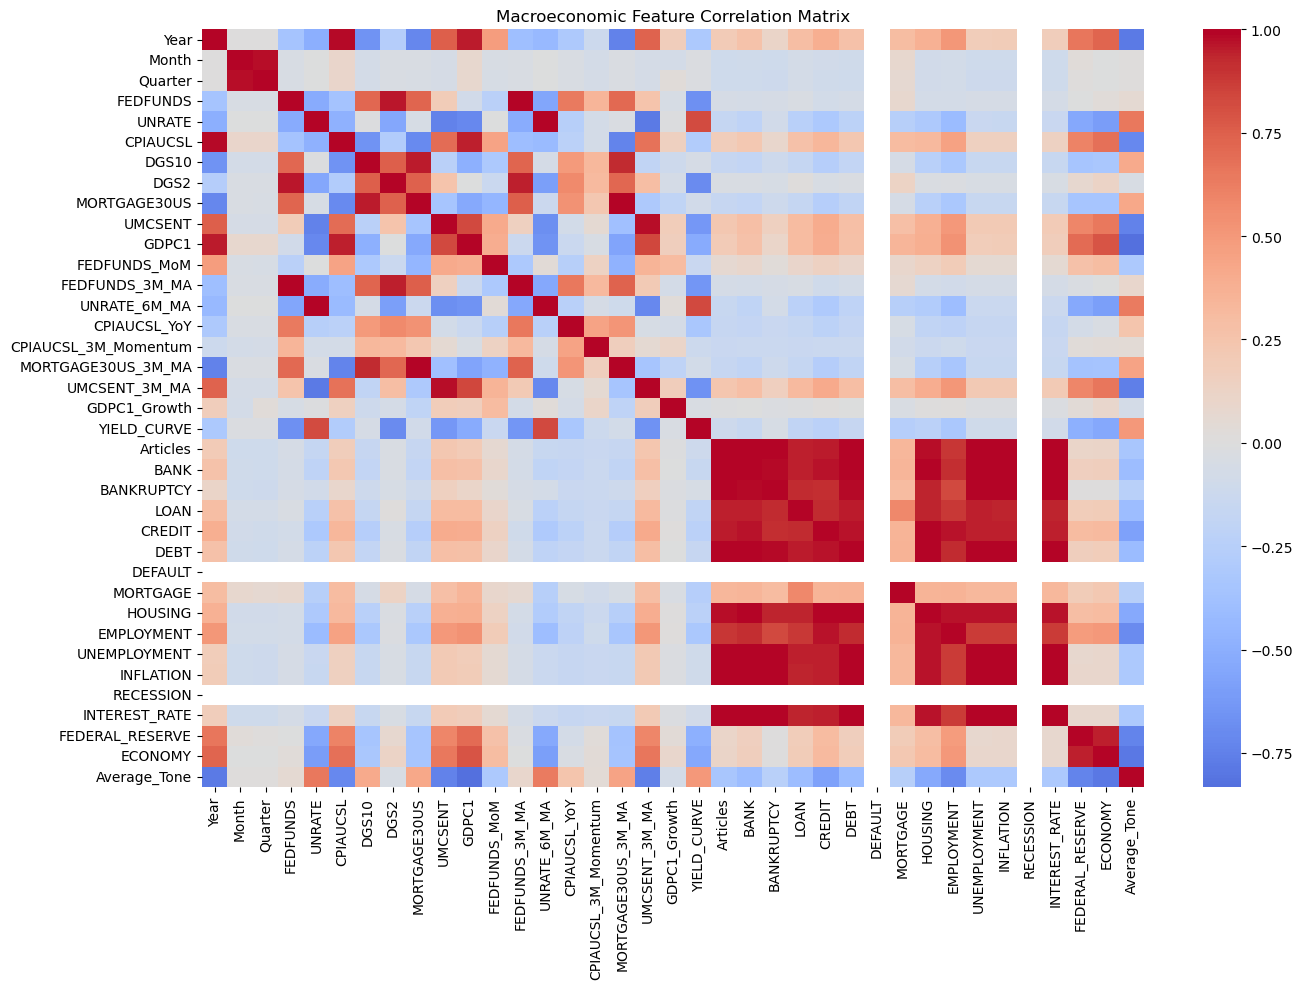

In [124]:
# CORRELATION VISUALISATION
# ------------------------------------

plt.figure(figsize=(14,10))

sns.heatmap(correlation_matrix,cmap="coolwarm",center=0)

plt.title("Macroeconomic Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(FIGURE_DIR /"macro_correlation_heatmap.png",dpi=300)

plt.show()

In [125]:
# QUALITY SUMMARY
# -----------------------------------------------------

quality_summary = {

    "Observations":

    macroeconomic_feature_store.shape[0],

    "Features":

    len(numeric_features),

    "Missing Values":

    int(macroeconomic_feature_store.isna().sum().sum()),

    "High Correlation Pairs":

    len(high_correlations),

    "Date Coverage":

    f"{macroeconomic_feature_store['YearMonth'].min()} to {
    
    macroeconomic_feature_store['YearMonth'].max()}"}

quality_summary_df = pd.DataFrame(quality_summary,index=[0])

display(quality_summary_df)

quality_summary_df.to_csv(REPORT_DIR /"macro_feature_quality_summary.csv",index=False)

logger.info("Feature Store Quality Assessment completed.")

,Observations,Features,Missing Values,High Correlation Pairs,Date Coverage
0,144,37,0,73,2007-01 to 2018-12


2026-07-16 21:52:17,454 | INFO | Feature Store Quality Assessment completed.


#### Macroeconomic Feature Engineering
##### Purpose
##### -----------------------------------------------------------------------------
##### Transform the validated Macroeconomic Feature Store into a predictive feature
##### set for credit risk modelling.
##### These engineered features will later be merged with Lending Club loans to
##### create Matrix D.

In [126]:
# CREATE WORKING COPY
# ------------------------------------------

macro_features = macroeconomic_feature_store.copy()

logger.info("Working copy created.")

2026-07-16 21:52:22,682 | INFO | Working copy created.


In [127]:
# SORT CHRONOLOGICALLY
# --------------------------------

macro_features = (macro_features.sort_values("YearMonth").reset_index(drop=True))

logger.info("Feature store sorted chronologically.")

2026-07-16 21:52:23,585 | INFO | Feature store sorted chronologically.


In [128]:
# CREATE LAG FEATURES
# ------------------------------------------

lag_features = [

    "UNRATE",

    "FEDFUNDS",

    "CPIAUCSL",

    "Average_Tone"]

for feature in lag_features:

    macro_features[f"{feature}_LAG1"] = macro_features[feature].shift(1)

    macro_features[f"{feature}_LAG3"] = macro_features[feature].shift(3)

logger.info("Lag features created.")

2026-07-16 21:52:25,352 | INFO | Lag features created.


In [129]:
# ROLLING AVERAGES
# ----------------------------------

rolling_features = [

    "UNRATE",

    "FEDFUNDS",

    "Average_Tone"]

for feature in rolling_features:

    macro_features[f"{feature}_MA3"] = (

        macro_features[feature]

        .rolling(window=3).mean())

logger.info("Rolling averages created.")

2026-07-16 21:52:26,514 | INFO | Rolling averages created.


In [130]:
# MONTHLY CHANGES
# -------------------------------

change_features = [

    "UNRATE",

    "FEDFUNDS",

    "Average_Tone"]

for feature in change_features:

    macro_features[f"{feature}_CHANGE"] = (

        macro_features[feature]

        .diff())

logger.info("Monthly change variables created.")

2026-07-16 21:52:27,911 | INFO | Monthly change variables created.


In [131]:
# ECONOMIC STRESS INDEX
# ----------------------------------------------

macro_features["ECONOMIC_STRESS_INDEX"] = (

    macro_features["UNRATE"]

    + macro_features["FEDFUNDS"]

    + macro_features["CPIAUCSL_YoY"])

logger.info("Economic Stress Index created.")

2026-07-16 21:52:28,847 | INFO | Economic Stress Index created.


In [132]:
# CREDIT SENTIMENT INDEX
# -----------------------------------

macro_features["CREDIT_SENTIMENT_INDEX"] = (

    macro_features["DEFAULT"]

    + macro_features["BANKRUPTCY"]

    + macro_features["DEBT"]

    + macro_features["LOAN"])

logger.info("Credit Sentiment Index created.")

2026-07-16 21:52:30,623 | INFO | Credit Sentiment Index created.


In [133]:
# RECESSION FLAG
# ----------------------------------

macro_features["RECESSION_FLAG"] = (

    macro_features["UNRATE"]

    > macro_features["UNRATE"].median()

).astype(int)

logger.info("Recession indicator created.")

2026-07-16 21:52:31,473 | INFO | Recession indicator created.


In [134]:
# INTEREST RATE REGIME
# ------------------------------------------------

macro_features["HIGH_RATE_ENVIRONMENT"] = (

    macro_features["FEDFUNDS"]

    > macro_features["FEDFUNDS"].median()

).astype(int)

logger.info("Interest rate regime created.")

2026-07-16 21:52:32,545 | INFO | Interest rate regime created.


In [135]:
# HANDLE ENGINEERED MISSING VALUES
# -------------------------------------------

macro_features = (macro_features.fillna(method="bfill"))

logger.info("Engineered missing values handled.")

2026-07-16 21:52:33,322 | INFO | Engineered missing values handled.


In [136]:
# FEATURE INVENTORY
# ---------------------------------------------------------

feature_inventory = pd.DataFrame({

    "Feature": macro_features.columns,

    "Data Type": macro_features.dtypes.astype(str)})

display(feature_inventory.head())

feature_inventory.to_csv(METADATA_DIR /"macro_feature_inventory.csv",index=False)

,Feature,Data Type
DATE,DATE,datetime64[ns]
Year,Year,int64
Month,Month,int64
Quarter,Quarter,int64
YearMonth,YearMonth,object


In [137]:
# ENGINEERED FEATURE SUMMARY
# -------------------------------------------

new_features = [col
                
                for col in macro_features.columns
                    
                if col not in macroeconomic_feature_store.columns]

summary = pd.DataFrame({"New Feature": new_features})

display(summary)

summary.to_csv(REPORT_DIR /"engineered_macro_features.csv",index=False)

logger.info(f"{len(new_features)} engineered features created.")

,New Feature
0,UNRATE_LAG1
1,UNRATE_LAG3
2,FEDFUNDS_LAG1
3,FEDFUNDS_LAG3
4,CPIAUCSL_LAG1
5,CPIAUCSL_LAG3
6,Average_Tone_LAG1
7,Average_Tone_LAG3
8,UNRATE_MA3
9,FEDFUNDS_MA3


2026-07-16 21:52:36,643 | INFO | 18 engineered features created.


#### Feature Selection
##### Purpose
##### -----------------------------------------------------------------------------
##### Select the most informative macroeconomic features for integration with the
##### Lending Club loan dataset.

In [138]:
# CREATE WORKING COPY
# --------------------------------

macro_selected = macro_features.copy()

logger.info("Working copy created.")

2026-07-16 21:52:39,781 | INFO | Working copy created.


In [139]:
# REMOVE CONSTANT FEATURES
# -------------------------------

constant_features = [col
                     
                     for col in macro_selected.columns
                         
                     if macro_selected[col].nunique() <= 1]

macro_selected.drop(columns=constant_features,inplace=True)

logger.info(f"{len(constant_features)} constant features removed.")

2026-07-16 21:52:40,737 | INFO | 2 constant features removed.


In [140]:
# REMOVE DUPLICATE FEATURES
# ----------------------------------

duplicate_features = []

columns = macro_selected.columns

for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        if macro_selected[columns[i]].equals(

            macro_selected[columns[j]]):
            
            duplicate_features.append(columns[j])

macro_selected.drop(

    columns=duplicate_features,

    inplace=True)

logger.info(f"{len(duplicate_features)} duplicate features removed.")

2026-07-16 21:52:42,148 | INFO | 0 duplicate features removed.


In [141]:
# REMOVE HIGHLY CORRELATED FEATURES
# ---------------------------------------------------------------

numeric_df = macro_selected.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    
    np.triu(np.ones(corr_matrix.shape),
            
            k=1).astype(bool))

high_corr_features = [column
                      
                      for column in upper.columns
                          
                      if any(upper[column] > 0.95)]

macro_selected.drop(columns=high_corr_features,inplace=True)

logger.info(f"{len(high_corr_features)} highly correlated features removed.")

2026-07-16 21:52:43,102 | INFO | 30 highly correlated features removed.


In [142]:
# FEATURE INVENTORY
# --------------------------------------------------

selected_inventory = pd.DataFrame({

    "Feature": macro_selected.columns,

    "Data Type": macro_selected.dtypes.astype(str)})

display(selected_inventory.head())

selected_inventory.to_csv(REPORT_DIR /"selected_features.csv",index=False)

,Feature,Data Type
DATE,DATE,datetime64[ns]
Year,Year,int64
Month,Month,int64
YearMonth,YearMonth,object
FEDFUNDS,FEDFUNDS,float64


In [143]:
# REMOVED FEATURE REPORT
# --------------------------------

removed = pd.DataFrame({

    "Constant Features":

    pd.Series(constant_features),

    "Duplicate Features":

    pd.Series(duplicate_features),

    "High Correlation":

    pd.Series(high_corr_features)})

display(removed)

removed.to_csv(REPORT_DIR /"removed_features.csv",index=False)

,Constant Features,Duplicate Features,High Correlation
0,DEFAULT,NaN,Quarter
1,RECESSION,NaN,CPIAUCSL
2,NaN,NaN,DGS2
3,NaN,NaN,MORTGAGE30US
4,NaN,NaN,GDPC1
5,NaN,NaN,FEDFUNDS_3M_MA
6,NaN,NaN,UNRATE_6M_MA
7,NaN,NaN,MORTGAGE30US_3M_MA
8,NaN,NaN,UMCSENT_3M_MA
9,NaN,NaN,BANK


In [144]:
# FEATURE SELECTION SUMMARY
# ---------------------------------------

summary = pd.DataFrame({

    "Metric":[

        "Original Features",

        "Final Features",

        "Constant Removed",

        "Duplicate Removed",

        "High Correlation Removed"],

    "Value":[

        macro_features.shape[1],

        macro_selected.shape[1],

        len(constant_features),

        len(duplicate_features),

        len(high_corr_features)]})

display(summary)

summary.to_csv(REPORT_DIR /"feature_selection_summary.csv",index=False)

logger.info("Feature selection completed.")

,Metric,Value
0,Original Features,57
1,Final Features,25
2,Constant Removed,2
3,Duplicate Removed,0
4,High Correlation Removed,30


2026-07-16 21:52:48,895 | INFO | Feature selection completed.


In [145]:
# FINAL FEATURE STORE
# ------------------------------------

display(macro_selected.head())

print()

print("Production Feature Store Shape")

print("-" * 60)

print(macro_selected.shape)

,DATE,Year,Month,YearMonth,FEDFUNDS,UNRATE,DGS10,UMCSENT,FEDFUNDS_MoM,CPIAUCSL_YoY,CPIAUCSL_3M_Momentum,GDPC1_Growth,YIELD_CURVE,Articles,LOAN,MORTGAGE,FEDERAL_RESERVE,ECONOMY,Average_Tone,Average_Tone_LAG3,UNRATE_CHANGE,Average_Tone_CHANGE,ECONOMIC_STRESS_INDEX,RECESSION_FLAG,HIGH_RATE_ENVIRONMENT
0,2007-01-01,2007,1,2007-01,5.25,4.6,4.759524,96.9,0.01,4.294696,1.212660,0.000000,-0.116667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.1,0.0,14.144696,0,1
1,2007-02-01,2007,2,2007-02,5.26,4.5,4.722632,91.3,0.01,4.294696,1.212660,0.000000,-0.126316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.1,0.0,14.054696,0,1
2,2007-03-01,2007,3,2007-03,5.26,4.4,4.564545,88.4,0.00,4.294696,1.212660,0.000000,-0.009091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.1,0.0,13.954696,0,1
3,2007-04-01,2007,4,2007-04,5.25,4.5,4.693810,87.1,-0.01,4.294696,1.212660,0.611762,0.027619,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,14.044696,0,1
4,2007-05-01,2007,5,2007-05,5.25,4.4,4.746364,88.3,0.00,4.294696,1.238334,0.000000,-0.020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.1,0.0,13.944696,0,1



Production Feature Store Shape
------------------------------------------------------------
(144, 25)


#### EXPORT PRODUCTION FEATURE STORE
##### Purpose
##### -----------------------------------------------------------------------------
##### Export the final validated macroeconomic feature store for downstream
##### machine learning pipelines.

In [146]:
# CREATE EXPORT DIRECTORY
# -------------------------------------

FEATURE_STORE_DIR = PROJECT_ROOT / "data" / "feature_store"

FEATURE_STORE_DIR.mkdir(parents=True, exist_ok=True)

In [147]:
# EXPORT CSV
# --------------------------

csv_path = FEATURE_STORE_DIR / "macroeconomic_feature_store.csv"

macro_selected.to_csv(csv_path,index=False)

logger.info("CSV exported.")

2026-07-16 21:52:56,366 | INFO | CSV exported.


In [148]:
# EXPORT PARQUET
# -------------------------

parquet_path = FEATURE_STORE_DIR / "macroeconomic_feature_store.parquet"

macro_selected.to_parquet(parquet_path,index=False)

logger.info("Parquet exported.")

2026-07-16 21:52:57,972 | INFO | Parquet exported.


In [149]:
# FEATURE DICTIONARY
# -------------------------------------------

feature_dictionary = pd.DataFrame({

    "Feature": macro_selected.columns,

    "DataType": macro_selected.dtypes.astype(str),

    "MissingValues": macro_selected.isna().sum(),

    "UniqueValues": macro_selected.nunique()})

feature_dictionary.to_csv(FEATURE_STORE_DIR /"feature_dictionary.csv",index=False)

display(feature_dictionary.head())

,Feature,DataType,MissingValues,UniqueValues
DATE,DATE,datetime64[ns],0,144
Year,Year,int64,0,12
Month,Month,int64,0,12
YearMonth,YearMonth,object,0,144
FEDFUNDS,FEDFUNDS,float64,0,61


In [150]:
# FEATURE STORE METADATA
# -------------------------------------

metadata = {

    "Feature Store": "Macroeconomic Feature Store",

    "Version": "1.0",

    "Rows": int(macro_selected.shape[0]),

    "Columns": int(macro_selected.shape[1]),

    "Created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "Source": ["FRED","GDELT"]}

with open(FEATURE_STORE_DIR /"metadata.json","w") as file:
    
    json.dump(metadata, file, indent=4)

logger.info("Metadata exported.")

2026-07-16 21:53:10,043 | INFO | Metadata exported.


#### GOVERNANCE & VALIDATION

##### Purpose
##### -----------------------------------------------------------------------------
##### Generate governance documentation for auditability,
##### reproducibility and enterprise deployment.

In [151]:
# DATASET CHECKSUM
# -----------------------------

checksum = hashlib.md5(pd.util.hash_pandas_object(
    
    macro_selected,
    
    index=True).values).hexdigest()

print(checksum)

edb787c8bdeb653a4c42ef363019633a


In [152]:
# GOVERNANCE REPORT
# --------------------------------------

governance = {

    "Dataset Name": "Macroeconomic Feature Store",

    "Rows": macro_selected.shape[0],

    "Columns": macro_selected.shape[1],

    "Missing Values": int(macro_selected.isna().sum().sum()),

    "Duplicate Rows": int(macro_selected.duplicated().sum()),

    "Checksum": checksum}

governance_df = pd.DataFrame(governance,index=[0])

display(governance_df)

governance_df.to_csv(REPORT_DIR /"governance_report.csv",index=False)

,Dataset Name,Rows,Columns,Missing Values,Duplicate Rows,Checksum
0,Macroeconomic Feature Store,144,25,0,0,edb787c8bdeb653a4c42ef363019633a


In [153]:
# DATA DICTIONARY
# --------------------------------------

dictionary = pd.DataFrame({

    "Feature": macro_selected.columns,

    "Type": macro_selected.dtypes.astype(str)})

dictionary.to_csv(REPORT_DIR /"data_dictionary.csv",index=False)

In [154]:
# VALIDATION REPORT
# ----------------------------------

validation = {

    "Validation Passed": True,

    "Null Values": int(macro_selected.isna().sum().sum()),

    "Duplicate Rows": int(macro_selected.duplicated().sum()),

    "Export Successful": True}

validation_df = pd.DataFrame(validation,index=[0])

display(validation_df)

validation_df.to_csv(REPORT_DIR /"validation_report.csv",index=False)

,Validation Passed,Null Values,Duplicate Rows,Export Successful
0,True,0,0,True


In [155]:
# SECTION 12 - EXECUTIVE SUMMARY
# ---------------------------------------------------

print("MACROECONOMIC FEATURE STORE PIPELINE COMPLETE")
print("=" * 40)

print(f"Total Records        : {macro_selected.shape[0]:,}")
print(f"Total Features       : {macro_selected.shape[1]:,}")
print(f"Missing Values       : {macro_selected.isna().sum().sum():,}")
print(f"Duplicate Rows       : {macro_selected.duplicated().sum():,}")

print("\nDatasets Integrated:")
print("- FRED")
print("- GDELT")

print("\nOutputs Generated:")
print("- Production Feature Store (.csv)")
print("- Production Feature Store (.parquet)")
print("- Feature Dictionary")
print("- Metadata")
print("- Governance Report")
print("- Validation Report")

logger.info("Notebook completed successfully.")

2026-07-16 21:53:16,224 | INFO | Notebook completed successfully.


MACROECONOMIC FEATURE STORE PIPELINE COMPLETE
Total Records        : 144
Total Features       : 25
Missing Values       : 0
Duplicate Rows       : 0

Datasets Integrated:
- FRED
- GDELT

Outputs Generated:
- Production Feature Store (.csv)
- Production Feature Store (.parquet)
- Feature Dictionary
- Metadata
- Governance Report
- Validation Report
